# PRISMA Strict Keyword Analysis: Hybrid Augmented Intelligence in VRP
This notebook categorizes literature using a binary keyword-matching approach to ensure maximum transparency and consistency for systematic review reporting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## 1. Data Loading & Robust Deduplication
Ensuring we reach the unique universe of N=626 records.

In [2]:
df = pd.read_csv('scopus_search5.csv')
initial_count = len(df)

df['clean_title'] = df['Title'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip()
df['clean_doi'] = df['DOI'].str.lower().str.strip()

with_doi = df[df['clean_doi'].notna()].drop_duplicates(subset='clean_doi', keep='first')
without_doi = df[df['clean_doi'].isna()]
df_clean = pd.concat([with_doi, without_doi]).drop_duplicates(subset='clean_title', keep='first')

print(f"Initial records: {initial_count} | Unique records: {len(df_clean)}")

Initial records: 627 | Unique records: 626


## 2. Strict Keyword Classification
Using your exhaustive lists to identify the three pillars.

In [3]:
vrp_terms = ['vehicle routing problem', 'vrp', 'vehicle routing', 'routing problem', 'distribution routing', 'logistics routing']
human_terms = ['human in the loop', 'human-in-the-loop', 'interactive optimization', 'interactive evolutionary', 'interactive search', 'interactive multiobjective', 'decision support', 'decision support system', 'decision-making', 'decision maker', 'decision-maker', 'expert knowledge', 'expert-driven', 'user-guided', 'participatory', 'multi-criteria', 'multicriteria', 'multi-objective decision', 'mcdm', 'ahp', 'topsis', 'electre', 'promethee', 'preference-based', 'preference learning', 'preference elicitation', 'preference modeling', 'preference', 'hitl', 'mca']
heuristic_terms = ['metaheuristic', 'hyper-heuristic', 'hyperheuristic', 'hybrid', 'hybrid algorithm', 'hybrid approach', 'hybrid method', 'hybrid intelligence', 'augmented intelligence', 'machine learning', 'reinforcement learning', 'deep learning', 'learning-based', 'learning guided', 'surrogate model', 'fuzzy', 'fuzzy logic', 'neuro-fuzzy', 'cognitive model', 'knowledge-based', 'data-driven']

In [4]:
# 1. Extract all unique keywords from the dataset
all_kws = []
for kw_str in df_clean['Author Keywords'].dropna():
    all_kws.extend([k.strip().lower() for k in str(kw_str).split(';')])
unique_kws = list(set(all_kws))

# 2. Represent pillars as vectors using your seed keywords
# (Pillar descriptions are built by joining your manual lists)
pillar_texts = [" ".join(vrp_terms), " ".join(human_terms), " ".join(heuristic_terms)]
vectorizer = TfidfVectorizer().fit(unique_kws + pillar_texts)
pillar_vectors = vectorizer.transform(pillar_texts)
kw_vectors = vectorizer.transform(unique_kws)

# 3. Calculate Similarity and Expand Lists
similarities = cosine_similarity(kw_vectors, pillar_vectors)
threshold = 0.1 # Adjust this to be more or less strict

def expand_list(pillar_idx):
    expanded = [unique_kws[i] for i, score in enumerate(similarities[:, pillar_idx]) if score > threshold]
    return list(set(expanded))

ml_vrp = expand_list(0)
ml_human = expand_list(1)
ml_heur = expand_list(2)


In [5]:
# --- Exporting ML-Expanded Keyword Lists ---

# Create a DataFrame to hold the expanded lists
# Since they have different lengths, we use a dictionary approach to handle the padding
export_data = {
    'VRP_Keywords': pd.Series(ml_vrp),
    'Human_Keywords': pd.Series(ml_human),
    'Heuristic_Keywords': pd.Series(ml_heur)
}

df_keywords_export = pd.DataFrame(export_data)

# Export to CSV
df_keywords_export.to_csv('Expanded_Keywords_Inventory.csv', index=False)

print(f"Export Complete: 'Expanded_Keywords_Inventory.csv' has been created.")
print(f"Counts: VRP ({len(ml_vrp)}), Human ({len(ml_human)}), Heuristic ({len(ml_heur)})")

# Preview of specific technical terms caught by the ML model:
print("\n--- Preview of Terms Caught by ML Expansion ---")
print(f"VRP (New): {ml_vrp[10:20]}")
print(f"Human (New): {ml_human[5:15]}")
print(f"Heur (New): {ml_heur[5:15]}")

Export Complete: 'Expanded_Keywords_Inventory.csv' has been created.
Counts: VRP (312), Human (88), Heuristic (188)

--- Preview of Terms Caught by ML Expansion ---
VRP (New): ['real life vehicle routing', 'network design problem', 'maritime routing', 'inventory-routing problem', 'non-ambulatory vehicle', 'location-inventory-routing problem', 'autonomous aerial vehicle', 'robust aircraft maintenance routing problem (ramrp)', 'the vehicle routing problem (vrp)', 'green vehicle routing problem with time windows (gvrptw)']
Human (New): ['real-time decision-making', 'multi-criteria routing', 'multi-criteria decision-making (mcdm)', 'risk preference', 'technique for order preference by similarity to ideal solution', 'the pareto set', 'multi-attribute decision making', 'collaborative decision attention network', 'multi-criteria vehicle routing problem', 'multi-objective vehicle routing']
Heur (New): ['hybrid models', 'hybrid metaheuristics', 'heuristic algorithm', 'reinforcement learning-ass

In [6]:
# --- Load Fixed Keywords from Excel/CSV ---
# Load the exported file
df_fixed_kw = pd.read_excel('kw_fixed.xls')

# Extract lists and drop any empty/NaN values
ml_vrp = df_fixed_kw['VRP_Keywords'].dropna().unique().tolist()
ml_human = df_fixed_kw['Human_Keywords'].dropna().unique().tolist()
ml_heur = df_fixed_kw['Heuristic_Keywords'].dropna().unique().tolist()

print(f"Loaded Fixed Keywords: VRP({len(ml_vrp)}), Human({len(ml_human)}), Heuristic({len(ml_heur)})")

Loaded Fixed Keywords: VRP(312), Human(67), Heuristic(188)


In [7]:

# 4. Re-classify papers using Expanded Lists
def ml_classification(row):
    text = (str(row['Title']) + " " + str(row['Author Keywords'])).lower()
    v = any(t in text for t in ml_vrp)
    hu = any(t in text for t in ml_human)
    he = any(t in text for t in ml_heur)
    return pd.Series([v, hu, he])

df_clean[['ex_VRP', 'ex_Human', 'ex_Heur']] = df_clean.apply(ml_classification, axis=1)

print(f"ML Expansion Complete.")
df_golden = df_clean[(df_clean['ex_Human'] & df_clean['ex_Heur'])]
print(f"New Golden Set Count: {df_golden.shape[0]}")
df_core = df_golden[df_golden['ex_VRP']].copy()
print(f"New Bridge Count: {df_core.shape[0]}")

ML Expansion Complete.
New Golden Set Count: 106
New Bridge Count: 99


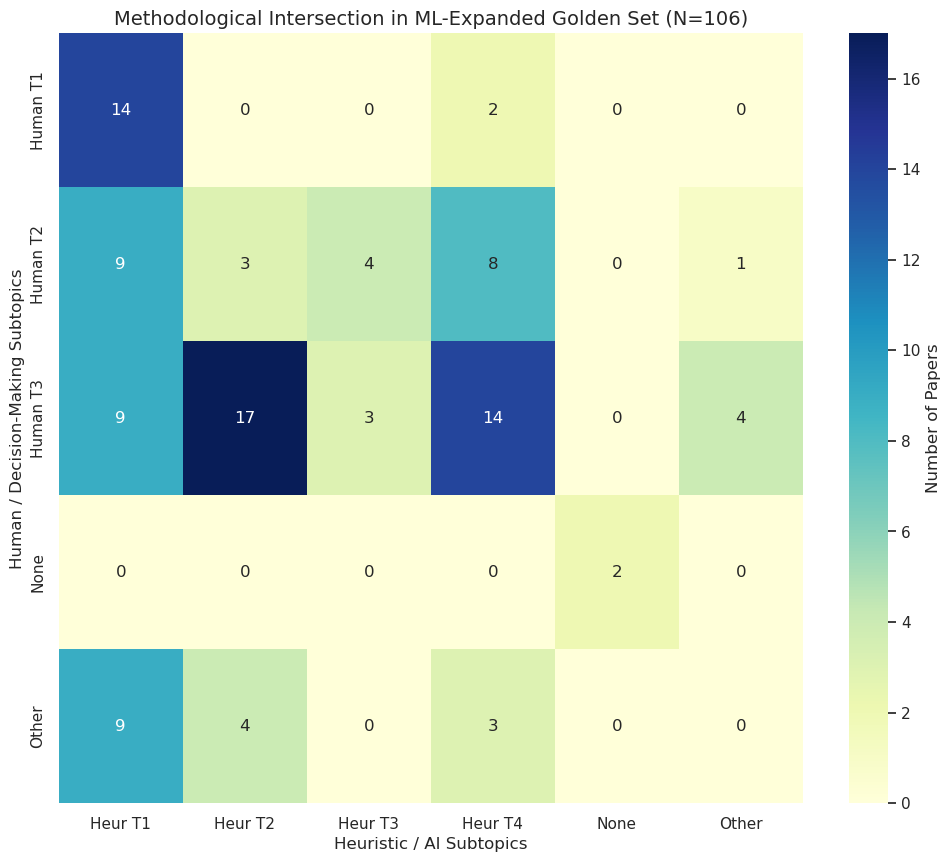

Heatmap generated successfully for 106 Golden papers.


In [8]:
# --- Heatmap for ML-Expanded Golden Set  ---
# 1. Define missing functions to ensure the cell is robust
def get_subtopic_mapping_v2_internal(df, terms_to_cluster, group_name, n_clusters=4):
    all_kws = []
    for kw_str in df['Author Keywords'].dropna():
        kws = [k.strip().lower() for k in str(kw_str).split(';')]
        relevant = [k for k in kws if any(term in k for term in terms_to_cluster)]
        all_kws.extend(relevant)
    unique_relevant = sorted(list(set(all_kws)))
    if len(unique_relevant) < n_clusters: return {}
    
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    X = vectorizer.fit_transform(unique_relevant)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    return {kw: f"{group_name} T{label+1}" for kw, label in zip(unique_relevant, labels)}

def assign_topics_internal(row, mapping):
    if pd.isna(row['Author Keywords']): return "None"
    paper_kws = [k.strip().lower() for k in str(row['Author Keywords']).split(';')]
    for kw in paper_kws:
        if kw in mapping: return mapping[kw]
    return "Other"

# 2. Update sub-topic mappings using the ML-expanded lists
vrp_map_ml = get_subtopic_mapping_v2_internal(df_clean, ml_vrp, "VRP", n_clusters=4)
human_map_ml = get_subtopic_mapping_v2_internal(df_clean, ml_human, "Human", n_clusters=3)
heur_map_ml = get_subtopic_mapping_v2_internal(df_clean, ml_heur, "Heur", n_clusters=4)

# 3. Assign sub-topics specifically to your new df_golden
df_golden['VRP_Subtopic'] = df_golden.apply(lambda x: assign_topics_internal(x, vrp_map_ml), axis=1)
df_golden['Human_Subtopic'] = df_golden.apply(lambda x: assign_topics_internal(x, human_map_ml), axis=1)
df_golden['Heur_Subtopic'] = df_golden.apply(lambda x: assign_topics_internal(x, heur_map_ml), axis=1)

# 4. Create the Relationship Matrix for the Golden papers
rel_matrix_ml = pd.crosstab(df_golden['Human_Subtopic'], df_golden['Heur_Subtopic'])

# 5. Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(rel_matrix_ml, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Papers'})

plt.title(f"Methodological Intersection in ML-Expanded Golden Set (N={len(df_golden)})", fontsize=14)
plt.ylabel("Human / Decision-Making Subtopics")
plt.xlabel("Heuristic / AI Subtopics")
plt.show()

# 6. Export the new Golden Set with its semantic DNA
df_golden.to_csv('PRISMA_ML_Golden_Set_Analysis.csv', index=False)

print(f"Heatmap generated successfully for {len(df_golden)} Golden papers.")

In [9]:
# --- MASTER TOPIC LEGEND: Titles, Keywords, and "Other" Analysis ---
from collections import Counter
import re

# 1. Internal Function for Clustering & Titling
def generate_topic_legend(df, terms_to_cluster, group_name, n_clusters=4):
    all_kws = []
    for kw_str in df['Author Keywords'].dropna():
        kws = [k.strip().lower() for k in str(kw_str).split(';')]
        relevant = [k for k in kws if any(term in k for term in terms_to_cluster)]
        all_kws.extend(relevant)
    
    unique_relevant = sorted(list(set(all_kws)))
    if len(unique_relevant) < n_clusters: return {}, {}

    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    X = vectorizer.fit_transform(unique_relevant)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    mapping = {kw: f"{group_name} T{label+1}" for kw, label in zip(unique_relevant, labels)}
    
    # Generate Titles & Print Inventory
    topic_titles = {}
    print(f"\n{'='*60}")
    print(f"PILLAR: {group_name}")
    print(f"{'='*60}")
    
    for i in range(n_clusters):
        topic_id = f"{group_name} T{i+1}"
        words_in_topic = [kw for kw, label in mapping.items() if label == topic_id]
        
        # Propose Title
        all_text = " ".join(words_in_topic).lower()
        word_counts = Counter(re.findall(r'\w+', all_text))
        stop_titles = ['vrp', 'problem', 'routing', 'vehicle', 'hybrid', 'human', 'optimization', 'method', 'decision']
        common = [w for w, c in word_counts.most_common(10) if w not in stop_titles]
        title = " ".join(common[:2]).title()
        topic_titles[topic_id] = title
        
        print(f"\n>>> {topic_id} | TITLE: {title}")
        print(f"    Keywords ({len(words_in_topic)}): {', '.join(words_in_topic[:10])}...")

    # Analyze "Other" for this pillar
    other_df = df[~df['Author Keywords'].str.contains('|'.join(terms_to_cluster), case=False, na=False)]
    other_kws = []
    for kw_str in other_df['Author Keywords'].dropna():
        other_kws.extend([k.strip().lower() for k in str(kw_str).split(';')])
    
    print(f"\n>>> {group_name} 'Other' (Meta-Keywords)")
    print(f"    These are papers where the topic was in the Title but keywords were generic:")
    print(f"    Top 10: {', '.join([f'{k}({c})' for k, c in Counter(other_kws).most_common(10)])}")
        
    return mapping, topic_titles

# 2. Execute and store for all three pillars (using your ML-expanded lists)
vrp_map_final, vrp_titles_final = generate_topic_legend(df_clean, ml_vrp, "VRP", n_clusters=4)
human_map_final, human_titles_final = generate_topic_legend(df_clean, ml_human, "Human", n_clusters=3)
heur_map_final, heur_titles_final = generate_topic_legend(df_clean, ml_heur, "Heur", n_clusters=4)


PILLAR: VRP

>>> VRP T1 | TITLE: Distribution Vehicles
    Keywords (203): adaptive routing, aircraft routing, aircraft routing problem, airline scheduling problem, algae fuel distribution network, arc routing, arc routing problem, assignment problem, auto carrier routing and loading, automated guided vehicle...

>>> VRP T2 | TITLE: Multi Electric
    Keywords (83): adaptive vehicle routing, autonomous electric vehicle, capacitated electric vehicle routing, capacitated vehicle routing, capacitated vehicle routing problem, capacitated vehicle routing problem with time windows, capacity vehicle routing problem, close-open mixed vehicle routing problem, collaborative electric vehicle routing problem, collaborative feeder vehicle routing problem...

>>> VRP T3 | TITLE: Logistics Chain
    Keywords (37): automotive inbound logistics, bi-directional logistics, city logistics, cold chain logistics, cold-chain logistics, collaborative city logistics, conflict zone logistics, cooperative logis

In [11]:
# --- Exporting PRISMA-Ready DOI List for Manual Screening ---

# 5. Exporting the Classified Sets
def save_dois_formatted(df, filename):
    # Drop NaNs, strip whitespace, and get unique DOIs
    dois = df['DOI'].dropna().astype(str).str.strip().unique()
    
    with open(filename, 'w') as f:
        for i, doi in enumerate(dois):
            # Formatted for direct copy-paste into database advanced search
            f.write(f'"{doi}"')
            
            if i < len(dois) - 1:
                f.write(' OR\n')
            else:
                f.write('\n')
                
    return len(dois)

# Export the Golden Set (Human + Heuristics)
if 'df_golden' in locals() and not df_golden.empty:
    count_gold = save_dois_formatted(df_golden, 'gold_dois_list.txt')
    print(f"✅ Created 'gold_dois_list.txt' with {count_gold} DOIs (Human ∩ Heuristics).")

# Export the Core Bridge Set (Human ∩ Heuristics ∩ VRP)
if 'df_core' in locals() and not df_core.empty:
    count_bridge = save_dois_formatted(df_core, 'bridge_dois_list.txt')
    print(f"✅ Created 'bridge_dois_list.txt' with {count_bridge} DOIs (VRP Core).")

✅ Created 'gold_dois_list.txt' with 101 DOIs (Human ∩ Heuristics).
✅ Created 'bridge_dois_list.txt' with 95 DOIs (VRP Core).
